# EDA: Трансферное обучение для классификации джетов

## 1. Источник данных

В работе используется **ATLAS Top Tagging Open Data Set** — набор симулированных событий с джетами,
подготовленный коллаборацией ATLAS.

Данные содержат информацию на трех уровнях:
- **jet-level** — агрегированные характеристики всего джета;
- **constituent-level** — характеристики отдельных частиц, составляющих джет;
- **high-level** — заранее сконструированные физические признаки.

В рамках текущего проекта основной акцент сделан на **constituent-level данных**,
так как они содержат наибольшее количество информации для задачи джет-теггинга.

---

## 2. Объем и структура данных

Для проведения EDA использовалась подвыборка:
- количество джетов: примерно 50 000;
- максимальное число конституентов на джет: до 200 (с последующим ограничением до 80);
- исходные признаки конституентов:  
  `pT`, `η`, `φ`, `E`.

Данные содержат zero-padding для отсутствующих конституентов.

**Выявленные особенности и ограничения данных:**
- значительное количество zero-padding для отсутствующих конституентов;
- сильная асимметрия распределений энергии и импульса;
- слабая визуальная разделимость классов на уровне отдельных конституентов.

---

## 3. Визуализация признаков на уровне джета

На уровне агрегированных признаков джета
(масса, импульс, псевдобыстрота, азимутальный угол)
уже можно наблюдать различия между сигналом (top-quark jets) и фоном.

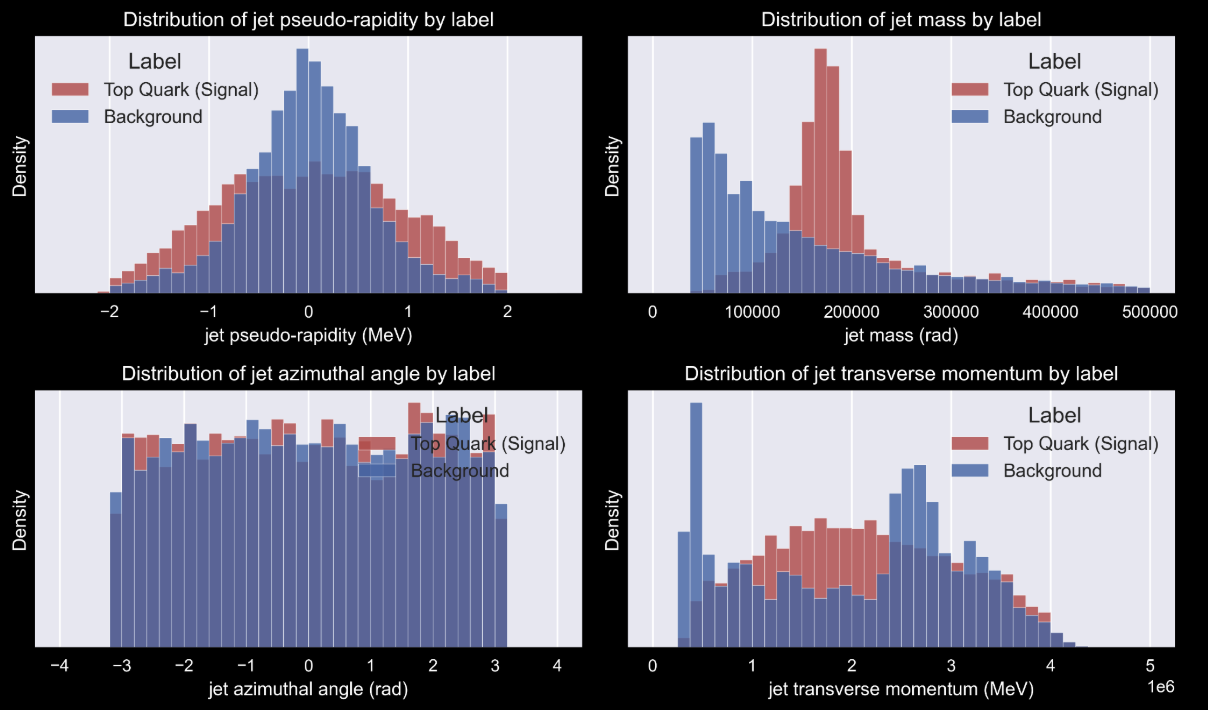

**Выводы:**
- распределения по классам частично разделимы визуально;
- информация на уровне джета потенциально полезна,
  но может быть недостаточной для высокоточного теггинга.

---

## 4. Визуализация признаков на уровне конституентов

Для признаков отдельных конституентов визуальная разделимость
между сигналом и фоном значительно слабее.

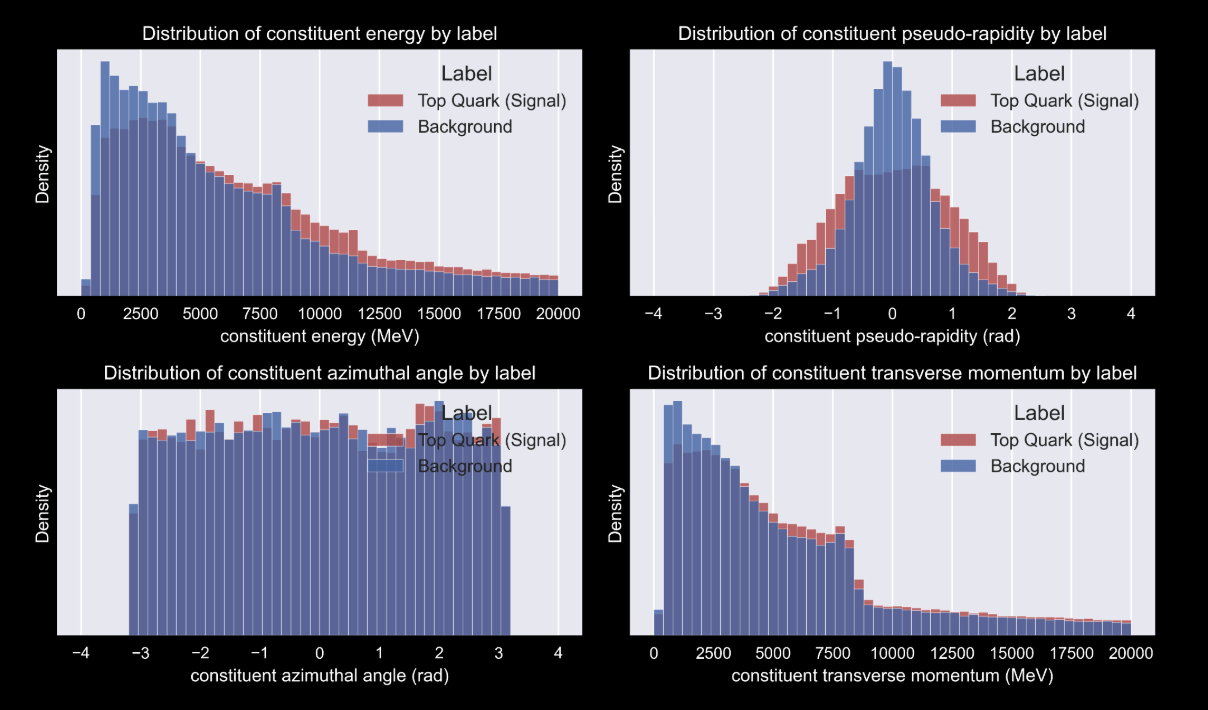


**Выводы:**
- различия между классами трудно выявить «на глаз»;
- предполагается, что нейронные сети смогут извлечь
  сложные корреляции, недоступные простому визуальному анализу.

---


## 5. Предобработка данных

Сырые constituent-level данные обладают следующими особенностями:
- широкий динамический диапазон энергии и импульса;
- циклическая природа угла φ;
- зависимость признаков от ориентации джета.

Для устранения этих проблем применяется физически мотивированная предобработка,
адаптированная из официального кода коллаборации ATLAS:
- центрирование в плоскости η–φ;
- логарифмирование `pT` и `E`;
- нормализация относительно суммарных характеристик джета;
- вычисление радиальной координаты `R`.

После предобработки каждый конституент описывается 7 признаками.

Цель предобработки - получить инвариантное и численно стабильное представление джета,
пригодное для обучения нейронных сетей.

---

## 6. Основные выводы EDA

- constituent-level данные являются наиболее информативными,
  но требуют сложных моделей для извлечения признаков;
- предобработка критически важна для успешного обучения;
- визуальный анализ подтверждает целесообразность использования
  глубоких нейронных сетей и методов трансферного обучения.
  
На основании результатов EDA принято решение **обучать модели
на данных уровня конституентов**, поскольку они содержат
наибольшее количество информации, релевантной задаче классификации джетов.
